# Optimization Techniques on MNIST Dataset
This notebook explores various optimization techniques for training neural networks on the MNIST dataset. The focus will be on different optimization strategies including Adaptive Learning Rates, SGD, Mini-Batch Gradient Descent, and Learning Rate Adjustments. Each section will provide a practical task related to these techniques.

Seyed Ali Vakilzadeh
401102789

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0

# One-hot encode labels
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
print(x_train.shape)
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)
print(x_train.shape)
# Example: Initializing with 64 hidden neurons and 10 output classes

(60000, 28, 28)
(60000, 784)


## Adaptive Learning Rates

## Implementing a Simple Neural Network from Scratch

### Building the Network
Define the architecture of a simple feedforward neural network with one hidden layer. You will need to manually initialize the weights and biases.

**TODO:** Initialize Parameters
Objective: Create a function to initialize weights and biases for all layers of the network.
Instructions:
- Initialize weights with small random values and biases with zeros.
- Use numpy for creating arrays and operations.

Hint: Use np.random.randn for weights and np.zeros for biases. Scale weights by 0.1.

In [7]:
def initialize_parameters(input_size, hidden_size, output_size):
    """
    Initialize weights and biases for a simple feedforward neural network.

    Parameters:
    - input_size: Number of input features.
    - hidden_size: Number of neurons in the hidden layer.
    - output_size: Number of output classes.

    Returns:
    - parameters: A dictionary containing weights and biases.
    """
    # Initialize weights and biases
    W1 = np.random.randn(input_size, hidden_size) * 0.01  # Corrected shape of W1
    b1 = np.zeros(hidden_size)
    W2 = np.random.randn(hidden_size, output_size) * 0.01
    b2 = np.zeros(output_size)

    parameters = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
    return parameters




TODO: Define Activation Functions
Objective: Implement commonly used activation functions.
Instructions:
 - Define the ReLU and Sigmoid activation functions.
 - Ensure each function works with numpy arrays and supports both forward and derivative (gradient) computations.


In [6]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x >= 0, 1, 0)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def softmax(x):
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)

def softmax_derivative(x):
    s = softmax(x.reshape(1, -1)).reshape(-1, 1)
    return np.diag(s) - s @ s.T

TODO: Perform forward propagation through the network.

    Parameters:
    - X: Input data (shape: number of examples x input size).
    - parameters: Dictionary containing weights and biases.

    Returns:
    - A2: Output of the network (after activation).
    - cache: Dictionary containing intermediate values for backpropagation.

In [8]:
def forward_propagation(X, parameters):
    """
    Perform forward propagation through the network.

    Parameters:
    - X: Input data (shape: number of examples x input size).
    - parameters: Dictionary containing weights and biases.

    Returns:
    - A2: Output of the network (after activation).
    - cache: Dictionary containing intermediate values for backpropagation.
    """
    W1 = parameters['W1']
    W2 = parameters['W2']
    b1 = parameters['b1']
    b2 = parameters['b2']

    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = softmax(Z2)

    cache = {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2}
    return A2, cache

TODO: Implement the loss function. Compute the categorical cross-entropy loss.

    Parameters:
    - y_true: True labels (one-hot encoded).
    - y_pred: Predicted probabilities (output of the network).

    Returns:
    - loss: Computed loss.

In [9]:
def compute_loss(y_true, y_pred):
    """
    Compute the categorical cross-entropy loss.

    Parameters:
    - y_true: True labels (one-hot encoded).
    - y_pred: Predicted probabilities (output of the network).

    Returns:
    - loss: Computed loss.
    """
    # Ensure numerical stability by clipping predictions
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)

    if(y_true.shape != y_pred.shape):
        y_pred = y_pred.T
    m = y_true.shape[0]
    loss = -np.sum(y_true * np.log(y_pred)) / m

    return loss


TODO: Implement backpropagation for the network and Perform backward propagation through the network.

    Parameters:
    - X: Input data.
    - y_true: True labels.
    - parameters: Dictionary containing weights and biases.
    - cache: Intermediate values from forward propagation.

    Returns:
    - gradients: Dictionary containing gradients for weights and biases.

In [10]:
def backward_propagation(X, y_true, parameters, cache):
    """
    Perform backward propagation through the network.

    Parameters:
    - X: Input data.
    - y_true: True labels.
    - parameters: Dictionary containing weights and biases.
    - cache: Intermediate values from forward propagation.

    Returns:
    - gradients: Dictionary containing gradients for weights and biases.
    """
    # Retrieve cached values
    W2 = parameters['W2']
    Z1, A1, A2 = cache['Z1'], cache['A1'], cache['A2']

    m = X.shape[0]
    dZ2 = (A2 - y_true) / m

    db2 = np.sum(dZ2, axis=0)
    dW2 = A1.T @ dZ2

    dA1 = dZ2 @ W2.T

    dZ1 = dA1 * relu_derivative(Z1)
    db1 = np.sum(dZ1, axis=0)
    dW1 = X.T @ dZ1

    grads={"Z2": dZ2, "b2": db2, "W2": dW2, "A1": A1, "Z1": dZ1, "b1": db1, "W1": dW1}
    return grads


TODO: Update the parameters using gradient descent.

    Parameters:
    - parameters: Current weights and biases.
    - gradients: Calculated gradients.
    - learning_rate: Learning rate for updates.

    Returns:
    - parameters: Updated weights and biases.

In [11]:
def update_parameters(parameters, gradients, learning_rate=0.01):
    """
    Update parameters using gradient descent.

    Parameters:
    - parameters: Current weights and biases.
    - gradients: Calculated gradients.
    - learning_rate: Learning rate for updates.

    Returns:
    - parameters: Updated weights and biases.
    """
    parameters["W1"] -= learning_rate * gradients["W1"]
    parameters["b1"] -= learning_rate * gradients["b1"]
    parameters["W2"] -= learning_rate * gradients["W2"]
    parameters["b2"] -= learning_rate * gradients["b2"]

    return parameters


TODO: Train the model by changing the hidden layer size (such as [32, 64, 128]) and observe the impact on network performance during training.

    Train the neural network model.

    Parameters:
    - X_train: Training data.
    - y_train: One-hot encoded labels.
    - hidden_size: Number of neurons in the hidden layer.
    - epochs: Number of training epochs.
    - learning_rate: Learning rate for optimization.

In [ ]:
# Training Loop
def train_model(X_train, y_train, hidden_size, epochs=50, learning_rate=0.01):
    """
    Train the neural network model.

    Parameters:
    - X_train: Training data.
    - y_train: One-hot encoded labels.
    - hidden_size: Number of neurons in the hidden layer.
    - epochs: Number of training epochs.
    - learning_rate: Learning rate for optimization.
    """
    parameters = initialize_parameters(X_train.shape[1], hidden_size, y_train.shape[1])

    cache = None
    gradients = None
    losses = []

    print(f"Training with hidden layer size: {hidden_size}")

    for i in range(epochs):
        y_pred, cache = forward_propagation(X_train, parameters)

        gradients = backward_propagation(X_train, y_train, parameters, cache)

        parameters = update_parameters(parameters, gradients, learning_rate)

        losses.append(compute_loss(y_pred=y_pred, y_true=y_train))

        if ((i+1) % 10) == 0:
            print(f"Epoch {i+1}, Loss: {np.round(losses[i], 3)}")

    return losses

hidden_sizes = [32, 64, 128]
for hidden_size in hidden_sizes:
    train_model(x_train, y_train, hidden_size, epochs=20)
    print("")

Training with hidden layer size: 32
Epoch 10, Loss: 2.301
Epoch 20, Loss: 2.3

Training with hidden layer size: 64
Epoch 10, Loss: 2.302
Epoch 20, Loss: 2.3

Training with hidden layer size: 128
Epoch 10, Loss: 2.302
Epoch 20, Loss: 2.299



TODO: Implement Adam Optimizer

1. Initialize Parameters: Create variables to store the moment estimates (first and second) for each parameter.

    Parameters:
    - parameters: Dictionary containing weights and biases.

    Returns:
    - v: First moment vector (initialized to zeros).
    - s: Second moment vector (initialized to zeros).
    - t: Time step (initialized to 0).

2. Update Rules: Implement the update rules based on the gradients, learning rate, and moment estimates.


In [ ]:
def initialize_adam(parameters):
    """
    Initialize the Adam optimizer variables.

    Parameters:
    - parameters: Dictionary containing weights and biases.

    Returns:
    - v: First moment vector (initialized to zeros).
    - s: Second moment vector (initialized to zeros).
    - t: Time step (initialized to 0).
    """
    v = {}
    s = {}
    t = 0

    for key in parameters:
        v[key] = np.zeros_like(parameters[key])
        s[key] = np.zeros_like(parameters[key])

    return v, s, t


def update_parameters_with_adam(parameters, gradients, v, s, t, learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
    """
    Update parameters using the Adam optimizer.

    Parameters:
    - parameters: Current weights and biases.
    - gradients: Calculated gradients.
    - v: First moment vector.
    - s: Second moment vector.
    - t: Time step.
    - learning_rate: Learning rate for updates.
    - beta1: Exponential decay rate for the first moment estimates.
    - beta2: Exponential decay rate for the second moment estimates.
    - epsilon: Small constant for numerical stability.


    Returns:
    - parameters: Updated weights and biases.
    - v: Updated first moment vector.
    - s: Updated second moment vector.
    - t: Updated time step.
    """
    t += 1  # Increment time step
    v_corrected = {}
    s_corrected = {}

    for key in parameters:
        v[key] = beta1 * v[key] + (1 - beta1) * gradients[ key]

        s[key] = beta2 * s[key] + (1 - beta2) * (gradients[key] ** 2)

        v_corrected[key] = v[key] / (1 - beta1 ** t)

        s_corrected[key] = s[key] / (1 - beta2 ** t)


        parameters[key] -= learning_rate * v_corrected[key] / (np.sqrt(s_corrected[key]) + epsilon)

    return parameters, v, s, t


TODO: Implement Adam optimizer into the training loop.

In [ ]:
def train_model_with_adam(X_train, y_train, hidden_size, epochs=50, learning_rate=0.001):
    """
    Train the neural network model using Adam optimizer.

    Parameters:
    - X_train: Training data.
    - y_train: One-hot encoded labels.
    - hidden_size: Number of neurons in the hidden layer.
    - epochs: Number of training epochs.
    - learning_rate: Learning rate for optimization.
    """
    input_size = X_train.shape[1]  # Number of features
    output_size = y_train.shape[1]  # Number of output classes
    parameters = initialize_parameters(input_size, hidden_size, output_size)
    v, s, t = initialize_adam(parameters)
    losses = []

    for i in range(epochs):
      y_pred, cache = forward_propagation(X_train, parameters)

      gradients = backward_propagation(X_train, y_train, parameters, cache)

      parameters = update_parameters_with_adam(parameters, gradients, v, s, t, learning_rate=learning_rate)

      losses.append(compute_loss(y_pred=y_pred, y_true=y_train))

      if ((i+1) % 10) == 0:
          print(f"Epoch {i+1}, Loss: {np.round(losses[i], 3)}")

    return losses



### Compare Adam and RMSprop


TODO: First, implement the RMSprop optimizer. The RMSprop optimizer uses a moving average of squared gradients to normalize the gradient, which helps to stabilize the updates.

In [ ]:
def initialize_rmsprop(parameters):
    """
    Initialize the RMSprop variables.

    Parameters:
    - parameters: Dictionary containing weights and biases.

    Returns:
    - s: Second moment vector (initialized to zeros).
    """
    s = {}
    for key in parameters:
        s[key] = np.zeros_like(parameters[key])
    return s


def update_parameters_with_rmsprop(parameters, gradients, s, learning_rate=0.001, beta=0.9, epsilon=1e-8):
    """
    Update parameters using the RMSprop optimizer.

    Parameters:
    - parameters: Current weights and biases.
    - gradients: Calculated gradients.
    - s: Second moment vector.
    - learning_rate: Learning rate for updates.
    - beta: Exponential decay rate for the second moment estimates.
    - epsilon: Small constant for numerical stability.

    Returns:
    - parameters: Updated weights and biases.
    - s: Updated second moment vector.
    """
    for key in parameters:
        # Update the moving average of the squared gradients
        s[key] = beta * s[key] + (1 - beta) * (gradients[key] ** 2)

        # Update the parameters using RMSprop update rule
        parameters[key] -= learning_rate * gradients[key] / (np.sqrt(s[key]) + epsilon)

    return parameters, s


TODO: Modify the training loop to allow for both optimizers and store the loss history for comparison.

In [ ]:
def train_model(X_train, y_train, hidden_size, epochs=50, learning_rate=0.001, optimizer='adam'):
    """
    Train the neural network model using specified optimizer.

    Parameters:
    - X_train: Training data.
    - y_train: One-hot encoded labels.
    - hidden_size: Number of neurons in the hidden layer.
    - epochs: Number of training epochs.
    - learning_rate: Learning rate for optimization.
    - optimizer: The optimizer to use ('adam' or 'rmsprop').

    Returns:
    - loss_history: List of loss values over epochs.
    """
    input_size = X_train.shape[1]  # Number of features
    output_size = y_train.shape[1]  # Number of output classes

    # Initialize parameters
    parameters = initialize_parameters(input_size, hidden_size, output_size)

    # Initialize optimizer variables
    if optimizer == 'adam':
        v, s, t = initialize_adam(parameters)
    elif optimizer == 'rmsprop':
        s = initialize_rmsprop(parameters)
    else:
        raise ValueError("Optimizer must be 'adam' or 'rmsprop'.")

    loss_history = []

    for epoch in range(epochs):
        # Forward pass
        y_pred, cache = forward_propagation(X_train, parameters)

        # Compute gradients
        gradients = backward_propagation(X_train, y_train, parameters, cache)

        # Update parameters using the specified optimizer
        if optimizer == 'adam':
            parameters, v, s, t = update_parameters_with_adam(
                parameters, gradients, v, s, t, learning_rate=learning_rate
            )
        elif optimizer == 'rmsprop':
            parameters, s = update_parameters_with_rmsprop(
                parameters, gradients, s, learning_rate=learning_rate
            )

        # Compute loss
        loss = compute_loss(y_pred=y_pred, y_true=y_train)
        loss_history.append(loss)

        # Print loss every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}, Loss: {np.round(loss, 3)}")

    return loss_history

TODO:  Compare Both Optimizers. Create a function to train the model using both optimizers and plot the loss histories for comparison.

Training with Adam optimizer...
Epoch 10, Loss: 1.895
Epoch 20, Loss: 1.302
Epoch 30, Loss: 0.983
Epoch 40, Loss: 0.824
Training with RMSprop optimizer...
Epoch 10, Loss: 1.451
Epoch 20, Loss: 1.078
Epoch 30, Loss: 0.914
Epoch 40, Loss: 0.824


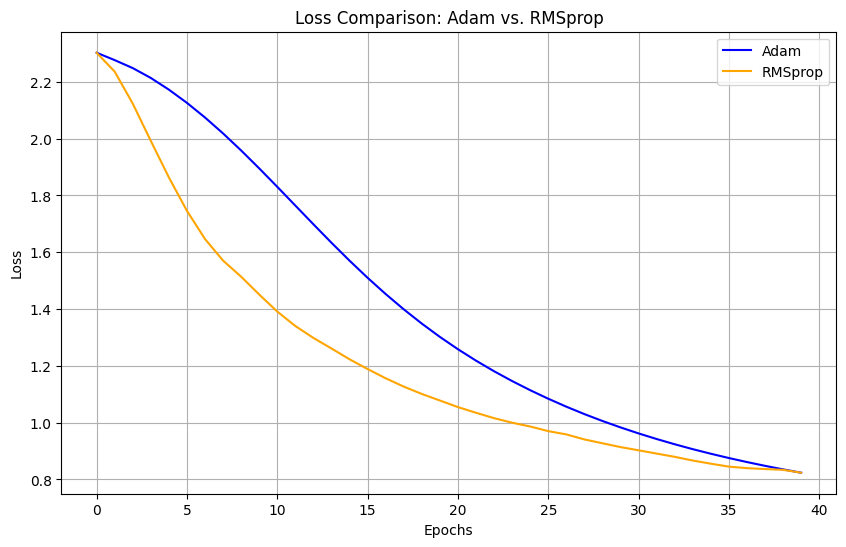

In [ ]:
def compare_optimizers(X_train, y_train, hidden_size, epochs=50, learning_rate=0.01):
    """
    Compare the Adam and RMSprop optimizers.

    Parameters:
    - X_train: Training data.
    - y_train: One-hot encoded labels.
    - hidden_size: Number of neurons in the hidden layer.
    - epochs: Number of training epochs.
    """
    print("Training with Adam optimizer...")
    adam_loss_history = train_model(
        X_train, y_train, hidden_size, epochs=epochs, learning_rate=learning_rate, optimizer='adam'
    )

    # Train with RMSprop optimizer
    print("Training with RMSprop optimizer...")
    rmsprop_loss_history = train_model(
        X_train, y_train, hidden_size, epochs=epochs, learning_rate=learning_rate, optimizer='rmsprop'
    )

    # Plot loss histories
    plt.figure(figsize=(10, 6))
    plt.plot(adam_loss_history, label='Adam', color='blue')
    plt.plot(rmsprop_loss_history, label='RMSprop', color='orange')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Comparison: Adam vs. RMSprop')
    plt.legend()
    plt.grid(True)
    plt.show()

compare_optimizers(x_train, y_train, hidden_size=128, epochs=40, learning_rate=0.001)

## Stochastic Gradient Descent (SGD)

### Impact of Different Learning Rates on SGD


Explore the impact of different learning rates on the training dynamics and performance of Stochastic Gradient Descent (SGD). This will allow us to observe how the learning rate affects convergence speed, stability, and final performance.

Steps for Implementing the Experiment

1. Define the SGD Optimizer: Implement a simple SGD optimizer.
2. Modify the Training Loop: Allow for different learning rates.
3. Train the Model: Run the training process with a set of predefined learning rates.
4. Visualize the Results: Plot the loss curves for each learning rate to compare their effects

1. Implement SGD Optimizer


In [ ]:
def update_parameters_with_sgd(parameters, gradients, learning_rate=0.01):
    """
    Update parameters using Stochastic Gradient Descent (SGD).

    Parameters:
    - parameters: Current weights and biases.
    - gradients: Calculated gradients.
    - learning_rate: Learning rate for updates.

    Returns:
    - parameters: Updated weights and biases.
    """
    for key in parameters:
        parameters[key] -= learning_rate * gradients[ key]
    return parameters

2. Modify the Training Loop


In [ ]:
def train_model_with_sgd(X_train, y_train, hidden_size, epochs=50, learning_rate=0.01):
    """
    Train the neural network model using SGD optimizer.

    Parameters:
    - X_train: Training data.
    - y_train: One-hot encoded labels.
    - hidden_size: Number of neurons in the hidden layer.
    - epochs: Number of training epochs.
    - learning_rate: Learning rate for optimization.

    Returns:
    - loss_history: List of loss values over epochs.
    """
    input_size = X_train.shape[1]  # Number of features
    output_size = y_train.shape[1]  # Number of output classes

    # Initialize model parameters
    parameters = initialize_parameters(input_size, hidden_size, output_size)

    # Initialize list to store loss values
    loss_history = []

    # Training loop
    for epoch in range(epochs):
      epoch_losses = []
      for X, y in zip(X_train, y_train):
          X = X.reshape(1, -1)
          y = y.reshape(1, -1)

          y_pred, cache = forward_propagation(X, parameters)

          gradients = backward_propagation(X, y, parameters, cache)

          parameters = update_parameters_with_sgd(parameters, gradients, learning_rate)

          epoch_losses.append(compute_loss(y_pred=y_pred, y_true=y))

      loss_history.append(np.mean(epoch_losses))
      if (epoch + 1) % 10 == 0:
          print(f"Epoch {epoch + 1}/{epochs}, Loss: {np.round(loss_history[epoch], 3)}")

    return loss_history


3. Experiment with Different Learning Rates



Training with learning rate: 0.001
Epoch 10/20, Loss: 0.321
Epoch 20/20, Loss: 0.258

Training with learning rate: 0.01
Epoch 10/20, Loss: 0.266
Epoch 20/20, Loss: 0.208

Training with learning rate: 0.1
Epoch 10/20, Loss: 2.137
Epoch 20/20, Loss: 2.181


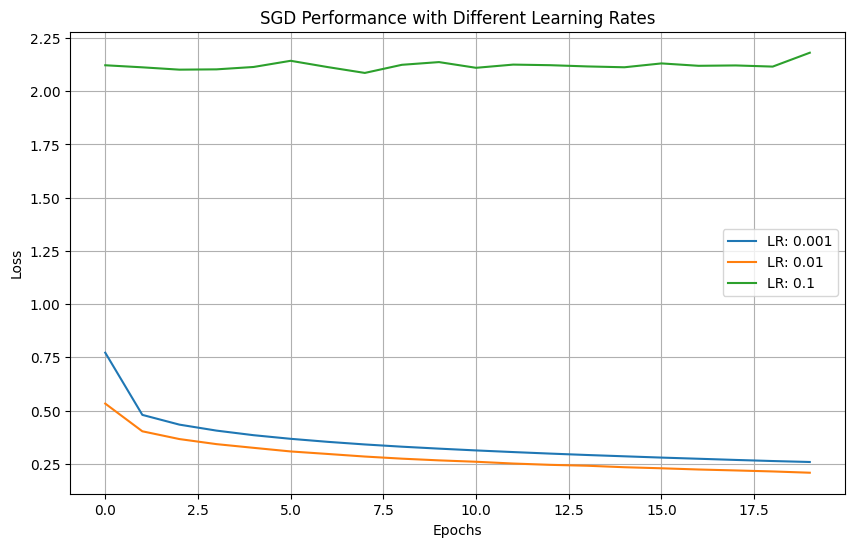

In [ ]:
def compare_learning_rates(X_train, y_train, hidden_size, epochs=50, learning_rates=[0.001, 0.01, 0.1]):
    """
    Compare the performance of SGD with different learning rates.

    Parameters:
    - X_train: Training data.
    - y_train: One-hot encoded labels.
    - hidden_size: Number of neurons in the hidden layer.
    - epochs: Number of training epochs.
    - learning_rates: List of learning rates to test.
    """
    results = {}

    for lr in learning_rates:
        print(f"\nTraining with learning rate: {lr}")
        # Train model with current learning rate
        loss_history = train_model_with_sgd(
            X_train, y_train, hidden_size=hidden_size, epochs=epochs, learning_rate=lr
        )
        # Store the loss history
        results[lr] = loss_history

    # Plot the results
    plt.figure(figsize=(10, 6))
    for lr, loss_history in results.items():
        plt.plot(loss_history, label=f'LR: {lr}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('SGD Performance with Different Learning Rates')
    plt.legend()
    plt.grid(True)
    plt.show()

    return results

results = compare_learning_rates(x_train, y_train, hidden_size=128, epochs=20, learning_rates=[0.001, 0.01, 0.1])

### SGD with Momentum vs. Classic SGD


TODO: Compare Stochastic Gradient Descent (SGD) with momentum and classic SGD, you can set up an experiment that trains the same model using both methods. This will help you observe differences in convergence speed and stability.

Steps for Implementing the Comparison:

1. Implement Classic SGD: Ensure you have a basic SGD implementation.(already implemented in the previous cells)

2. Implement SGD with Momentum: Add a momentum version of the SGD optimizer.

3. Modify the Training Loop: Allow for both optimizers in the training process.

4. Train the Model: Run the training process using both optimizers.

5. Visualize the Results: Plot the loss curves for each optimizer to compare their performance.

2. Implement SGD with Momentum


In [16]:
def initialize_momentum(parameters):
    """
    Initialize the momentum variables.

    Parameters:
    - parameters: Dictionary containing weights and biases.

    Returns:
    - v: Momentum variable (initialized to zeros).
    """
    v = {}
    for key in parameters:
        v[key] = np.zeros_like(parameters[key])
    return v


def update_parameters_with_momentum(parameters, gradients, v, learning_rate=0.01, beta=0.9):
    """
    Update parameters using SGD with momentum.

    Parameters:
    - parameters: Current weights and biases.
    - gradients: Calculated gradients.
    - v: Momentum variable.
    - learning_rate: Learning rate for updates.
    - beta: Exponential decay rate for momentum.

    Returns:
    - parameters: Updated weights and biases.
    - v: Updated momentum variable.
    """
    for key in parameters:
        v[key] = beta * v[key] + (1 - beta) * gradients[key]

        parameters[key] -= learning_rate * v[key]

    return parameters, v


3. Modify the Training Loop


In [15]:
def train_model_with_momentum(X_train, y_train, hidden_size, optimizer,epochs=50, learning_rate=0.01, beta=0.9):
    """
    Train the neural network model using specified optimizer.

    Parameters:
    - X_train: Training data.
    - y_train: One-hot encoded labels.
    - hidden_size: Number of neurons in the hidden layer.
    - epochs: Number of training epochs.
    - learning_rate: Learning rate for optimization.
    - optimizer: The optimizer to use ('sgd' or 'momentum').

    Returns:
    - loss_history: List of loss values over epochs.
    """
    input_size = X_train.shape[1]  # Number of features
    output_size = y_train.shape[1]  # Number of output classes

    # Initialize model parameters
    parameters = initialize_parameters(input_size, hidden_size, output_size)
    loss_history = []

    if optimizer == 'momentum':
        v = initialize_momentum(parameters)
    else:
        v = None  # No momentum for classic SGD

    for epoch in range(epochs):
        y_pred, cache = forward_propagation(X_train, parameters)

        loss = compute_loss(y_pred=y_pred, y_true=y_train)
        loss_history.append(loss)

        gradients = backward_propagation(X_train, y_train, parameters, cache)

        if optimizer == 'momentum':
            parameters, v = update_parameters_with_momentum(
                parameters, gradients, v, learning_rate=learning_rate, beta=beta
            )
        elif optimizer == 'sgd':
            parameters = update_parameters_with_sgd(
                parameters, gradients, learning_rate=learning_rate
            )
        else:
            raise ValueError("Invalid optimizer. Choose 'sgd' or 'momentum'.")

        # Log progress every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {np.round(loss, 3)}")

    return loss_history

4. Train the Model with Both Optimizers



Training with Classic SGD
Epoch 10/20, Loss: 2.3
Epoch 20/20, Loss: 2.296

Training with SGD with Momentum
Epoch 10/20, Loss: 2.302
Epoch 20/20, Loss: 2.3


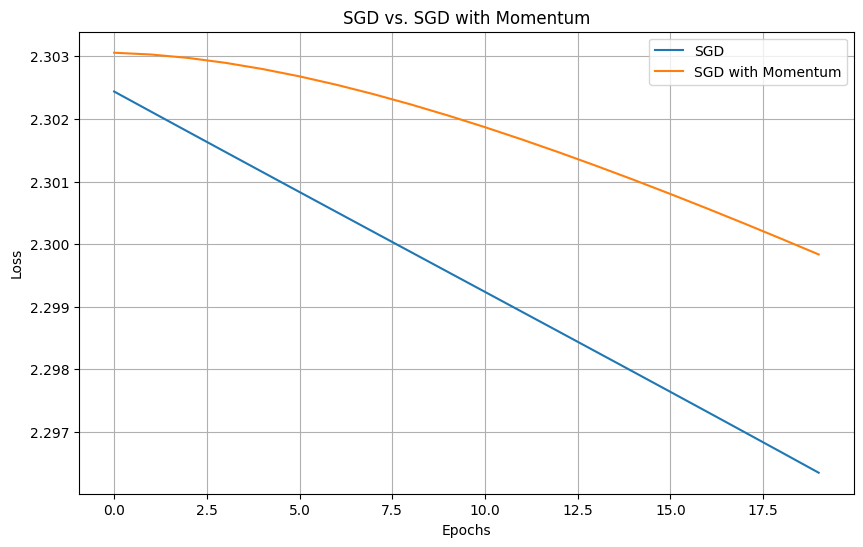

In [ ]:
def compare_sgd_methods(X_train, y_train, hidden_size, epochs=50, learning_rate=0.01, beta=0.9):
    """
    Compare the performance of classic SGD and SGD with momentum.

    Parameters:
    - X_train: Training data.
    - y_train: One-hot encoded labels.
    - hidden_size: Number of neurons in the hidden layer.
    - epochs: Number of training epochs.
    """
    print("\nTraining with Classic SGD")
    sgd_loss = train_model_with_momentum(X_train, y_train, hidden_size, 'sgd', epochs, learning_rate)

    print("\nTraining with SGD with Momentum")
    momentum_loss = train_model_with_momentum(X_train, y_train, hidden_size, 'momentum', epochs, learning_rate, beta)

    results = {
        "SGD": sgd_loss,
        "SGD with Momentum": momentum_loss
    }

    return results
results = compare_sgd_methods(x_train, y_train, hidden_size=128, epochs=20, learning_rate=0.01, beta=0.9)
plt.figure(figsize=(10, 6))
for method, loss_history in results.items():
    plt.plot(loss_history, label=method)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('SGD vs. SGD with Momentum')
plt.legend()
plt.grid(True)
plt.show()

## Mini-Batch Gradient Descent

### Mini-Batch Size Optimization

TODO: Investigate how different mini-batch sizes affect model performance, you can set up an experiment where you train the same model using various mini-batch sizes.

Steps for Implementing the Mini-Batch Size Experiment

1. Modify the Training Loop: Update the training loop to use mini-batches.
2. Train the Model: Run the training process with a set of predefined mini-batch sizes.
3. Evaluate Performance: Track training time and accuracy for each mini-batch size.
4. Print the training losses and accuracies for comparison.

1. Modify the Training Loop for Mini-Batches


In [24]:
def train_model_with_mini_batches(X_train, y_train, hidden_size, epochs=50, learning_rate=0.01, batch_size=32):
    """
    Train the neural network model using mini-batches.

    Parameters:
    - X_train: Training data of shape (num_instances, num_features).
    - y_train: One-hot encoded labels of shape (num_classes, num_instances).
    - hidden_size: Number of neurons in the hidden layer.
    - epochs: Number of training epochs.
    - learning_rate: Learning rate for optimization.
    - batch_size: Size of mini-batches.

    Returns:
    - loss_history: List of loss values over epochs.
    - accuracy_history: List of accuracy values over epochs.
    """
    input_size = X_train.shape[1]
    output_size = y_train.shape[1]
    parameters = initialize_parameters(input_size, hidden_size, output_size)
    losses = []
    accuracy_history = []
    n=X_train.shape[0]
    v = initialize_momentum(parameters)
    # Shuffle the training data
    indices = np.arange(X_train.shape[0])
    np.random.shuffle(indices)
    X_train = X_train[indices]
    y_train = y_train[indices]


    batches = [(X_train[i: min(i + batch_size, n)], y_train[i: min(i + batch_size, n)]) for i in range(0, n, batch_size)]
    for i in range(epochs):
        epoch_losses = []
        for X_batch, y_batch in batches:
            y_pred, cache = forward_propagation(X_batch, parameters)

            gradients = backward_propagation(X_batch, y_batch, parameters, cache)
            accuracy = compute_accuracy(y_pred, y_batch)
            parameters, v = update_parameters_with_momentum(parameters, gradients, v, learning_rate=learning_rate)

            epoch_losses.append(compute_loss(y_pred=y_pred, y_true=y_batch))

        losses.append(np.mean(epoch_losses))
        accuracy_history.append(accuracy)
        if ((i+1) % 10) == 0:
            print(f"Epoch {i+1}/{epochs}, Loss: {losses[i]:.4f}, Accuracy: {accuracy_history[i]:.4}")

    return losses,accuracy_history

2. Train the Model with Different Mini-Batch Sizes



Training with batch size 16...
Epoch 10/20, Loss: 0.3555, Accuracy: 0.6
Epoch 20/20, Loss: 0.2938, Accuracy: 0.5

Training with batch size 32...
Epoch 10/20, Loss: 0.4034, Accuracy: 0.2
Epoch 20/20, Loss: 0.3438, Accuracy: 0.3

Training with batch size 64...
Epoch 10/20, Loss: 0.4559, Accuracy: 0.4
Epoch 20/20, Loss: 0.4002, Accuracy: 0.4


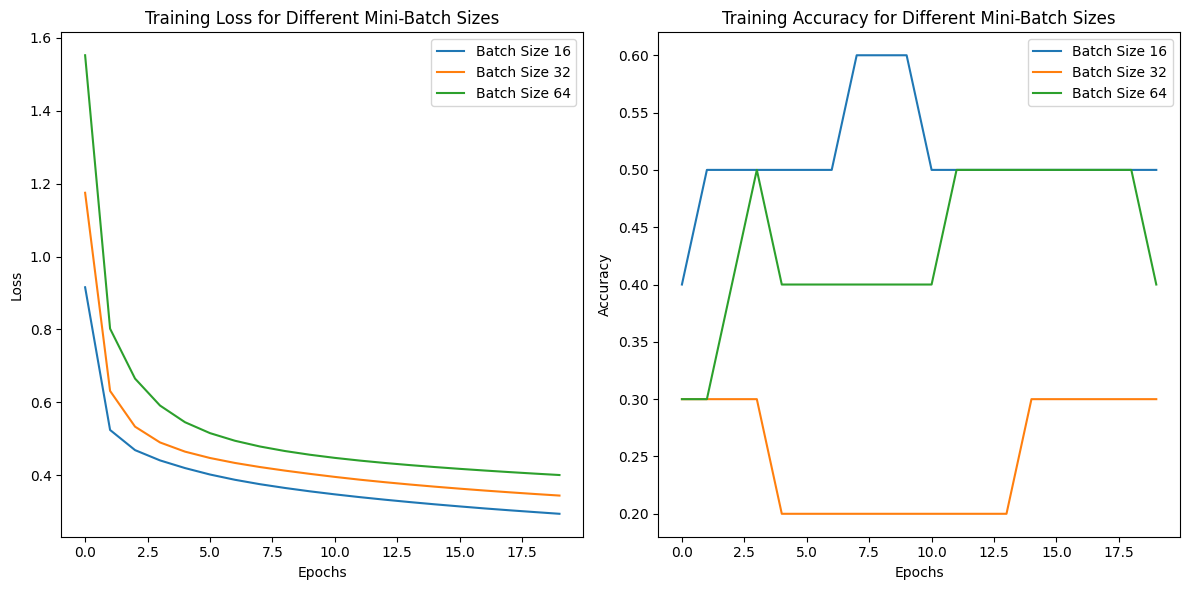

In [25]:
def compute_accuracy(y_pred, y_true):
    """
    Compute the accuracy of the model's predictions.

    Parameters:
    - y_pred: The predicted outputs (probabilities or logits) of shape (num_classes, num_instances).
    - y_true: The true labels in one-hot encoded format of shape (num_classes, num_instances).

    Returns:
    - accuracy: The accuracy of the predictions, a float value between 0 and 1.
    """
    predicted_classes = np.argmax(y_pred, axis=0)  # Shape: (num_instances,)

    true_classes = np.argmax(y_true, axis=0)  # Shape: (num_instances,)

    correct_predictions = np.sum(predicted_classes == true_classes)

    accuracy = correct_predictions / y_true.shape[1]

    return accuracy
def compare_mini_batch_sizes(X_train, y_train, hidden_size, epochs=50, batch_sizes=[16, 32, 64]):
    """
    Compare the performance of different mini-batch sizes and print results.

    Parameters:
    - X_train: Training data.
    - y_train: One-hot encoded labels.
    - hidden_size: Number of neurons in the hidden layer.
    - epochs: Number of training epochs.
    - batch_sizes: List of mini-batch sizes to test.
    """
    results = {}

    for batch_size in batch_sizes:
        print(f"\nTraining with batch size {batch_size}...")
        loss_history, accuracy_history = train_model_with_mini_batches(
            X_train, y_train, hidden_size, epochs=epochs, batch_size=batch_size
        )
        results[batch_size] = {
            'loss': loss_history,
            'accuracy': accuracy_history
        }

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    for batch_size in batch_sizes:
        plt.plot(results[batch_size]['loss'], label=f'Batch Size {batch_size}')
    plt.title("Training Loss for Different Mini-Batch Sizes")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    for batch_size in batch_sizes:
        plt.plot(results[batch_size]['accuracy'], label=f'Batch Size {batch_size}')
    plt.title("Training Accuracy for Different Mini-Batch Sizes")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

compare_mini_batch_sizes(x_train, y_train, hidden_size=128, epochs=20, batch_sizes=[16, 32, 64])

### Mini-Batch vs. Full-Batch Gradient Descent


TODO: Compare the efficiency and performance of mini-batch gradient descent against full-batch gradient descent.

1. Implement Full-Batch Gradient Descent: Ensure you have a full-batch gradient descent implementation.

2. Modify the Training Loop: Allow the training loop to handle both mini-batch and full-batch scenarios.

3. Train the Model: Run the training process using both methods and track their performance.

4. Print Results: Display the final loss and accuracy for both methods along with training times.

In [30]:
def train_model_full_batch(X_train, y_train, hidden_size, epochs=50, learning_rate=0.01):
    """
    Train the neural network model using full-batch gradient descent.

    Parameters:
    - X_train: Training data.
    - y_train: One-hot encoded labels.
    - hidden_size: Number of neurons in the hidden layer.
    - epochs: Number of training epochs.
    - learning_rate: Learning rate for optimization.

    Returns:
    - loss_history: List of loss values over epochs.
    - accuracy_history: List of accuracy values over epochs.
    """
    input_size = X_train.shape[1]  # Number of features
    output_size = y_train.shape[1]  # Number of output classes
    parameters = initialize_parameters(input_size, hidden_size, output_size)
    loss_history = []
    accuracy_history = []

    for epoch in range(epochs):
        y_pred, cache = forward_propagation(X_train, parameters)
        gradients = backward_propagation(X_train, y_train, parameters, cache)

        parameters = update_parameters(parameters, gradients, learning_rate=learning_rate)

        loss = compute_loss(y_pred, y_train)
        accuracy = np.mean((y_pred >= np.max(y_pred, axis=1, keepdims=True)).astype(float) * y_train)
        loss_history.append(loss)
        accuracy_history.append(accuracy)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

    return loss_history, accuracy_history

Training with Mini-Batch Gradient Descent:
Epoch 10/30, Loss: 0.4175, Accuracy: 0.3
Epoch 20/30, Loss: 0.3643, Accuracy: 0.3
Epoch 30/30, Loss: 0.3369, Accuracy: 0.4

Training with Full-Batch Gradient Descent:
Epoch 10/30, Loss: 31.0846, Accuracy: 0.0135
Epoch 20/30, Loss: 31.0825, Accuracy: 0.0154
Epoch 30/30, Loss: 31.0802, Accuracy: 0.0171


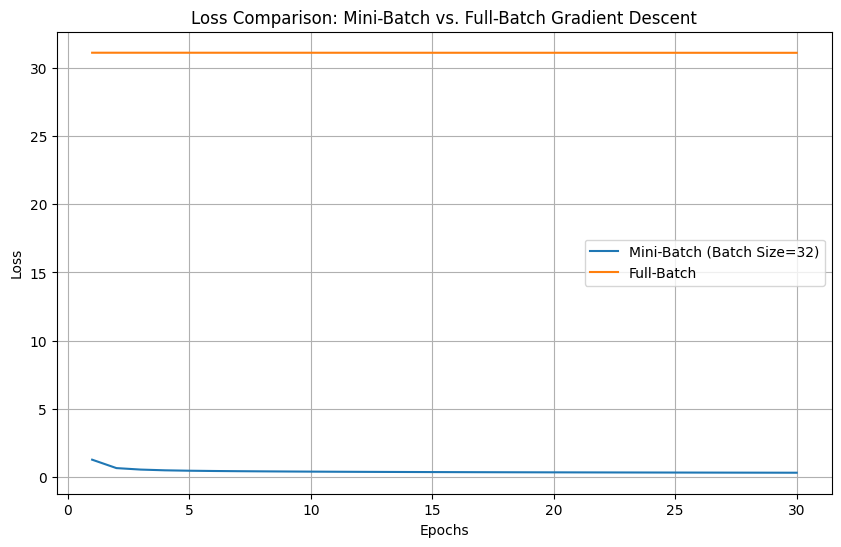


Final Accuracy with Mini-Batch Gradient Descent: 0.4000


In [31]:
def compare_mini_batch_and_full_batch(X_train, y_train, hidden_size, epochs=50, batch_size=32):
    """
    Compare the performance of mini-batch gradient descent against full-batch gradient descent.

    Parameters:
    - X_train: Training data.
    - y_train: One-hot encoded labels.
    - hidden_size: Number of neurons in the hidden layer.
    - epochs: Number of training epochs.
    - batch_size: Size of mini-batches for mini-batch gradient descent.
    """
    print("Training with Mini-Batch Gradient Descent:")
    mini_batch_loss, mini_batch_accuracy = train_model_with_mini_batches(
        X_train, y_train, hidden_size, epochs, learning_rate=0.01, batch_size=batch_size
    )

    # Train with full-batch gradient descent
    print("\nTraining with Full-Batch Gradient Descent:")
    full_batch_loss, full_batch_accuracy = train_model_full_batch(
        X_train, y_train, hidden_size, epochs, learning_rate=0.01
    )

    # Plot the loss history for comparison
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, epochs + 1), mini_batch_loss, label=f"Mini-Batch (Batch Size={batch_size})")
    plt.plot(range(1, epochs + 1), full_batch_loss, label="Full-Batch")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss Comparison: Mini-Batch vs. Full-Batch Gradient Descent")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Print final accuracies for comparison
    print(f"\nFinal Accuracy with Mini-Batch Gradient Descent: {mini_batch_accuracy[-1]:.4f}")
compare_mini_batch_and_full_batch(x_train, y_train, 32, epochs=30, batch_size=32)